## Importing Libraires

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading dataset

In [3]:
df = pd.read_csv('student-por.csv')

# 1. Dataset Understanding

### How many rows and columns are present in the dataset?

In [4]:
df.shape

(649, 33)

"There are 649 rows are 33 columns in the dataset"

### What are the names and meanings of all attributes?

In [5]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

| # | Attribute | Meaning |
|---|---|---|
| 1 | `school` | Student's school — GP (Gabriel Pereira) or MS (Mousinho da Silveira) |
| 2 | `sex` | Student's gender — M (Male) or F (Female) |
| 3 | `age` | Student's age (15 to 22) |
| 4 | `address` | Home location — U (Urban) or R (Rural) |
| 5 | `famsize` | Family size — LE3 (3 or less) or GT3 (more than 3) |
| 6 | `Pstatus` | Parents living together — T (Together) or A (Apart) |
| 7 | `Medu` | Mother's education level (0=none, 1=primary, 2=middle, 3=secondary, 4=higher) |
| 8 | `Fedu` | Father's education level (same scale) |
| 9 | `Mjob` | Mother's job (teacher, health, services, at_home, other) |
| 10 | `Fjob` | Father's job (same categories) |
| 11 | `reason` | Reason for choosing this school (home, reputation, course, other) |
| 12 | `guardian` | Student's guardian (mother, father, other) |
| 13 | `traveltime` | Home to school travel time (1=<15min, 2=15-30min, 3=30-60min, 4=>1hr) |
| 14 | `studytime` | Weekly study time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs) |
| 15 | `failures` | Number of past class failures (0 to 3) |
| 16 | `schoolsup` | Extra educational support from school (yes/no) |
| 17 | `famsup` | Educational support from family (yes/no) |
| 18 | `paid` | Extra paid classes (yes/no) |
| 19 | `activities` | Extracurricular activities (yes/no) |
| 20 | `nursery` | Attended nursery school (yes/no) |
| 21 | `higher` | Wants to pursue higher education (yes/no) |
| 22 | `internet` | Internet access at home (yes/no) |
| 23 | `romantic` | In a romantic relationship (yes/no) |
| 24 | `famrel` | Quality of family relationships (1=very bad, 5=excellent) |
| 25 | `freetime` | Free time after school (1=very low, 5=very high) |
| 26 | `goout` | Going out with friends (1=very low, 5=very high) |
| 27 | `Dalc` | Workday alcohol consumption (1=very low, 5=very high) |
| 28 | `Walc` | Weekend alcohol consumption (1=very low, 5=very high) |
| 29 | `health` | Current health status (1=very bad, 5=very good) |
| 30 | `absences` | Number of school absences (0 to 93) |
| 31 | `G1` | First term grade (0–20) |
| 32 | `G2` | Second term grade (0–20) |
| 33 | `G3` | Final grade (0–20) — **Target Variable** |

### What are the data types of each column?

In [6]:
print("Data Types of Each Column:")
print(df.dtypes)
print(f"\nTotal Numerical Columns : {df.select_dtypes(include='int64').shape[1]}")
print(f"Total Categorical Columns: {df.select_dtypes(include='str').shape[1]}")

Data Types of Each Column:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

Total Numerical Columns : 16
Total Categorical Columns: 17


### Are there any missing or duplicate values in the dataset?

In [7]:
print("Missing Values in Each Column:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

Missing Values in Each Column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total Missing Values: 0
Duplicate Rows: 0


## Missing & Duplicate Values

### Missing Values
- Checked using `df.isnull().sum()`
- **Result: 0 missing values** in all 33 columns
- Dataset is complete — no imputation needed

### Duplicate Rows
- Checked using `df.duplicated().sum()`
- **Result: 0 duplicate rows** found
- Every row represents a unique student

### Conclusion
> The dataset is clean with no missing or duplicate values.
> We can proceed directly to preprocessing.

### Which variables are numerical and which are categorical?

In [8]:
numerical = df.select_dtypes(include='int64').columns.tolist()
categorical = df.select_dtypes(include='str').columns.tolist()

print(f"Numerical Variables ({len(numerical)}):")
print(numerical)

print(f"\nCategorical Variables ({len(categorical)}):")
print(categorical)

Numerical Variables (16):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical Variables (17):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


### Summary

| Type | Count | Action |
|---|---|---|
| Numerical | 16 | Ready to use directly in model |
| Categorical | 17 | Will be encoded using Label Encoding in preprocessing |

# 2 Data Preprocessing

### How will missing values (if any) be handled?

- Checked in Dataset Understanding section using `df.isnull().sum()`
- Result: No missing values found in any column
- Therefore, no imputation or dropping of rows was required

### How will categorical variables be converted into numerical form?

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include='str').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding Complete ✅")
df.head()

Encoding Complete ✅


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,0,11,13,13


### Encoded Columns & Their Values

| Column | Original Values | Encoded Values |
|---|---|---|
| `school` | GP, MS | 0, 1 |
| `sex` | F, M | 0, 1 |
| `address` | R, U | 0, 1 |
| `famsize` | GT3, LE3 | 0, 1 |
| `Pstatus` | A, T | 0, 1 |
| `Mjob` | at_home, health, other, services, teacher | 0, 1, 2, 3, 4 |
| `Fjob` | at_home, health, other, services, teacher | 0, 1, 2, 3, 4 |
| `reason` | course, home, other, reputation | 0, 1, 2, 3 |
| `guardian` | father, mother, other | 0, 1, 2 |
| `schoolsup` | no, yes | 0, 1 |
| `famsup` | no, yes | 0, 1 |
| `paid` | no, yes | 0, 1 |
| `activities` | no, yes | 0, 1 |
| `nursery` | no, yes | 0, 1 |
| `higher` | no, yes | 0, 1 |
| `internet` | no, yes | 0, 1 |
| `romantic` | no, yes | 0, 1 |

### Which columns should be removed and why?

The following columns were removed from the dataset before model training:

| Column | Reason for Removal |
|---|---|
| `school` | Each school may follow a different grading system, making grades across schools incomparable. Including it could introduce noise and conflict into the model. |
| `guardian` | The identity of a guardian (mother, father, or other) has no direct impact on academic performance. What matters is the quality of the relationship, which is already captured by `famrel`. |
| `nursery` | Whether a student attended nursery school at age 4–5 has no meaningful relevance to their academic performance at age 15–22. It adds noise without predictive value. |
| `Pstatus` | Whether parents live together or apart does not directly reflect home environment quality. This effect is better represented by `famrel`. |
| `Dalc` + `Walc` | These two columns are being merged into a single feature `alcohol` in the Feature Engineering section. Keeping them separately would cause redundancy. |

In [10]:
df['alcohol'] = (df['Dalc'] + df['Walc']) / 2

cols_to_drop = ['school', 'guardian', 'nursery', 'Pstatus', 'Dalc', 'Walc']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['sex', 'age', 'address', 'famsize', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3', 'alcohol']


### How will you ensure the dataset is clean and consistent?

The following checks were performed to ensure the dataset is clean and consistent:

**1. Missing Values**
```python
print("Total Missing Values:", df.isnull().sum().sum())
```
> Result: **0 missing values** found across all 33 columns. No imputation required.

**2. Duplicate Rows**
```python
print("Duplicate Rows:", df.duplicated().sum())
```
> Result: **0 duplicate rows** found. Every row represents a unique student.

**3. Categorical Encoding**
```python
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include='str').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
```
> All **17 categorical columns** successfully converted to numerical form using Label Encoding.

**4. Irrelevant Column Removal**
> Columns `school`, `guardian`, `nursery`, `Pstatus`, `Dalc`, `Walc` were dropped — removing noise and redundancy from the dataset.

After all these steps, the dataset is fully numerical, contains no missing or duplicate values, and only relevant features remain.

### How will the target variable be created from G3?

A new column `pass` is created from `G3` without removing the original column, since `G3` is needed for Linear Regression (continuous prediction) while `pass` is used for Logistic Regression (Pass/Fail classification).

**Conversion Rule:**

| Condition | Label | Encoded As |
|---|---|---|
| G3 ≥ 10 | Pass | 1 |
| G3 < 10 | Fail | 0 |


In [11]:
df['pass'] = (df['G3'] >= 10).astype(int)
print(df['pass'].value_counts())


pass
1    549
0    100
Name: count, dtype: int64


# 3. Feature Selection


### Which features are most relevant for predicting student performance?


In [12]:
correlation = df.corr()['G3'].sort_values(ascending=False)
correlation

G3            1.000000
G2            0.918548
G1            0.826387
pass          0.663157
higher        0.332172
studytime     0.249789
Medu          0.240151
Fedu          0.211800
address       0.167637
internet      0.150025
Mjob          0.148252
reason        0.124969
famrel        0.063361
activities    0.059791
famsup        0.059206
Fjob          0.052953
famsize       0.045016
paid         -0.054898
schoolsup    -0.066405
goout        -0.087641
romantic     -0.090583
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
sex          -0.129077
alcohol      -0.208881
failures     -0.393316
Name: G3, dtype: float64

Based on correlation with `G3`, features are ranked as follows:

| Feature | Correlation | Interpretation |
|---|---|---|
| `G2` | 0.918 | Strongest predictor — second term grade directly reflects final performance |
| `G1` | 0.826 | First term grade also highly predictive |
| `higher` | 0.332 | Students who want higher education are more motivated |
| `studytime` | 0.249 | More study time leads to better grades |
| `Medu` | 0.240 | Mother's education level positively impacts performance |
| `Fedu` | 0.211 | Father's education level also has positive influence |
| `failures` | -0.393 | Strongest negative predictor — past failures heavily impact final grade |
| `alcohol` | -0.208 | Higher alcohol consumption negatively affects performance |
| `sex` | -0.129 | Slight negative correlation |
| `absences` | -0.091 | More absences lead to lower grades |

In [13]:
features = ['G1', 'G2', 'studytime', 'failures', 'higher', 
            'Medu', 'Fedu', 'absences', 'alcohol', 'internet']

X = df[features]
y_reg = df['G3']       # For Linear Regression
y_clf = df['pass']     # For Logistic Regression



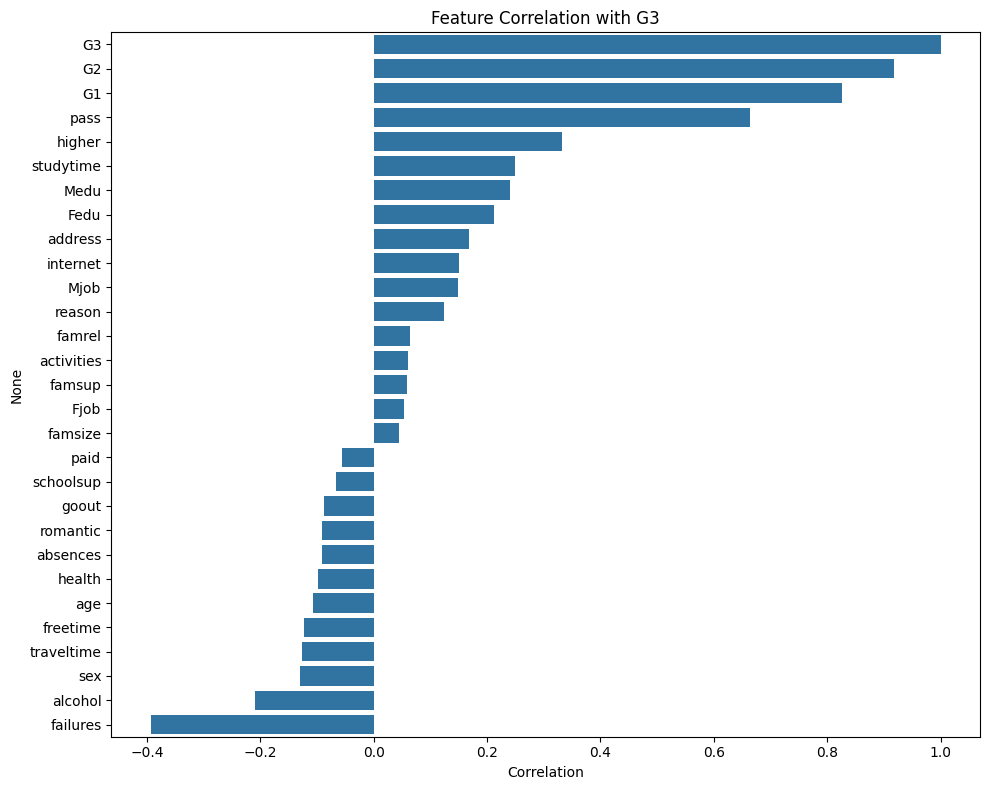

In [14]:
plt.figure(figsize=(10, 8))
sns.barplot(x=correlation.values, y=correlation.index)
plt.title('Feature Correlation with G3')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()


### Which columns are excluded from the model and on what criteria?

Columns were excluded on two levels:

**Level 1 — Dropped from dataset entirely** *(already done in preprocessing)*

| Column | Reason |
|---|---|
| `school` | Different grading systems cause inconsistency |
| `guardian` | Identity of guardian irrelevant to performance |
| `nursery` | Childhood detail with no relevance to current grades |
| `Pstatus` | Captured better by `famrel` |
| `Dalc` + `Walc` | Merged into single `alcohol` feature |

**Level 2 — Excluded from model input** *(low correlation with G3)*

| Column | Correlation | Reason |
|---|---|---|
| `famrel` | 0.063 | Very weak correlation with G3 |
| `activities` | 0.059 | Negligible impact on grades |
| `famsup` | 0.059 | Very weak signal |
| `paid` | -0.054 | Near-zero correlation |
| `goout` | -0.087 | Already captured partially by alcohol |
| `romantic` | -0.090 | Weak negative correlation |
| `health` | -0.098 | Weak signal |
| `freetime` | -0.122 | Low relevance |
| `traveltime` | — | Logistical detail, not academic |
| `famsize` | 0.045 | Too weak to be useful |
| `Fjob` | 0.052 | Very weak |
| `Mjob` | 0.148 | Captured better by `Medu` |
| `reason` | 0.124 | Weak and ambiguous signal |




In [19]:
df['risk_score'] = df['failures'] + df['absences']

New Features Correlation with G3:
alcohol      -0.208881
risk_score   -0.138393
Name: G3, dtype: float64


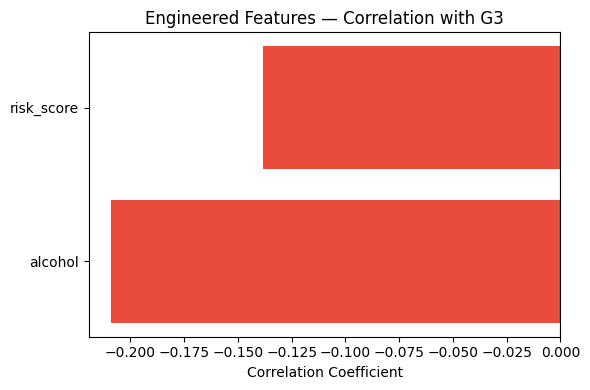

In [21]:
new_features = ['alcohol', 'risk_score']
new_corr = df.corr()['G3'][new_features]
print("New Features Correlation with G3:")
print(new_corr)

plt.figure(figsize=(6, 4))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in new_corr.values]
plt.barh(new_corr.index, new_corr.values, color=colors)
plt.title('Engineered Features — Correlation with G3')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Can we do feature engineering by adding a new feature?

Yes! Two new features were engineered:

**Feature 1 — `alcohol`**
```python
df['alcohol'] = (df['Dalc'] + df['Walc']) / 2
```
> Combines workday and weekend alcohol consumption into a single overall score.
> Correlation with G3: **-0.208** — moderate negative impact on performance.

**Feature 2 — `risk_score`**
```python
df['risk_score'] = df['failures'] + df['absences']
```
> Combines two negative indicators into a single "student at risk" score.
> Correlation with G3: **-0.138** — students with more failures and absences tend to perform worse.

**Engineered Features Correlation with G3:**

| Feature | Correlation | Interpretation |
|---|---|---|
| `alcohol` | -0.208 | Higher consumption → lower grades |
| `risk_score` | -0.138 | More failures + absences → lower grades |

# 4. Exploratory Data Analysis (EDA)

### What is the distribution of final grades (G3)?

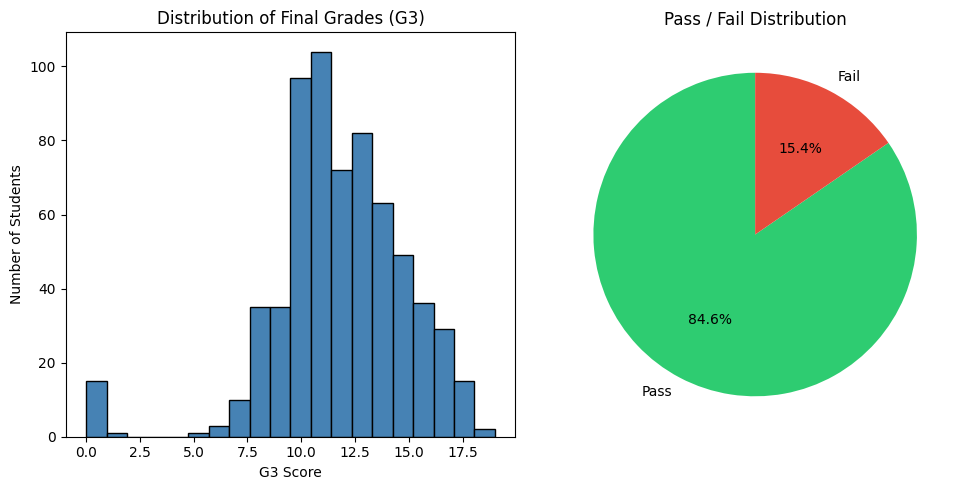

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64

Pass: 549 students
Fail: 100 students


In [22]:
plt.figure(figsize=(10, 5))

# Plot 1 - Histogram
plt.subplot(1, 2, 1)
plt.hist(df['G3'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('G3 Score')
plt.ylabel('Number of Students')

# Plot 2 - Pass/Fail Pie Chart
plt.subplot(1, 2, 2)
df['pass'].value_counts().plot.pie(
    labels=['Pass', 'Fail'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Pass / Fail Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

print(df['G3'].describe())
print(f"\nPass: {df['pass'].sum()} students")
print(f"Fail: {(df['pass'] == 0).sum()} students")

**Key Observations:**

| Metric | Value |
|---|---|
| Total Students | 649 |
| Mean Grade | 11.9 / 20 |
| Median Grade | 12.0 / 20 |
| Min / Max | 0 / 19 |
| Pass (G3 ≥ 10) | 549 students (84.6%) |
| Fail (G3 < 10) | 100 students (15.4%) |

- Distribution is **slightly left-skewed** — majority of students score between 10–14
- A small cluster of students scored **0** — likely dropouts or absentees on exam day
- Dataset is **imbalanced** — 84.6% Pass vs 15.4% Fail, which will be important during model evaluation

### Is there a relationship between study time and performance?

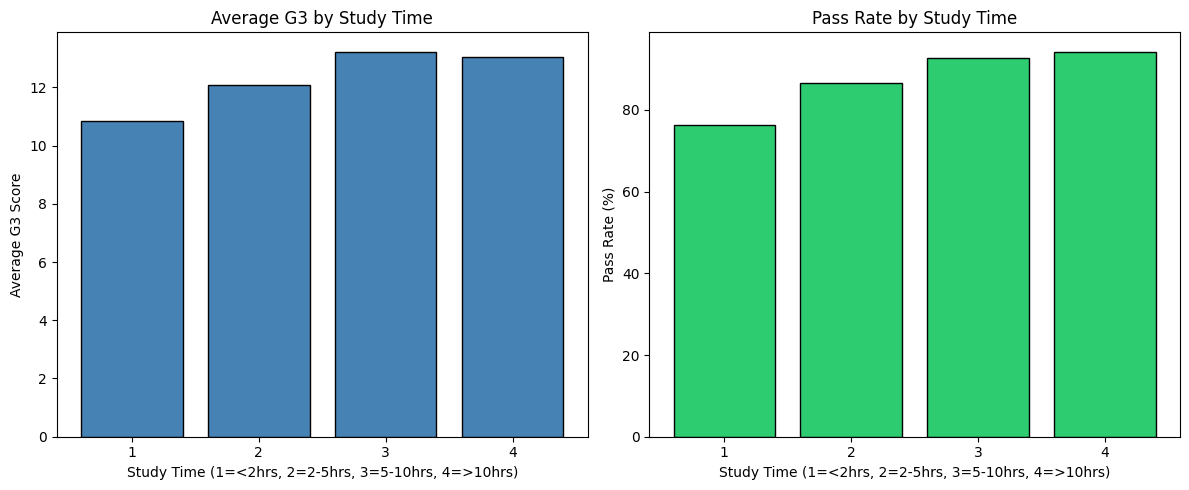

Average G3 by Study Time:
studytime
1    10.844340
2    12.091803
3    13.226804
4    13.057143
Name: G3, dtype: float64

Pass Rate by Study Time (%):
studytime
1    76.415094
2    86.557377
3    92.783505
4    94.285714
Name: pass, dtype: float64


In [23]:
plt.figure(figsize=(12, 5))

# Plot 1 - Average G3 per Study Time
plt.subplot(1, 2, 1)
study_perf = df.groupby('studytime')['G3'].mean()
plt.bar(study_perf.index, study_perf.values, color='steelblue', edgecolor='black')
plt.title('Average G3 by Study Time')
plt.xlabel('Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)')
plt.ylabel('Average G3 Score')
plt.xticks([1, 2, 3, 4])

# Plot 2 - Pass Rate per Study Time
plt.subplot(1, 2, 2)
pass_rate = df.groupby('studytime')['pass'].mean() * 100
plt.bar(pass_rate.index, pass_rate.values, color='#2ecc71', edgecolor='black')
plt.title('Pass Rate by Study Time')
plt.xlabel('Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)')
plt.ylabel('Pass Rate (%)')
plt.xticks([1, 2, 3, 4])

plt.tight_layout()
plt.show()

print("Average G3 by Study Time:")
print(study_perf)
print("\nPass Rate by Study Time (%):")
print(pass_rate)

**Results:**

| Study Time | Average G3 | Pass Rate |
|---|---|---|
| 1 — Less than 2 hrs | 10.84 | 76.4% |
| 2 — 2 to 5 hrs | 12.09 | 86.6% |
| 3 — 5 to 10 hrs | 13.23 | 92.8% |
| 4 — More than 10 hrs | 13.06 | 94.3% |

**Key Observations:**
- Clear **positive trend** — more study time → higher grades and pass rate
- Students studying less than 2 hrs have the lowest average G3 **(10.84)** and highest fail risk **(23.6%)**
- Jump from level 1 to level 2 is the most significant — **+1.25 points** in G3
- Level 3 and 4 are very close — suggesting **diminishing returns** beyond 5-10 hrs
- Pass rate jumps from **76.4% to 94.3%** going from least to most study time

### How do absences affect student results?

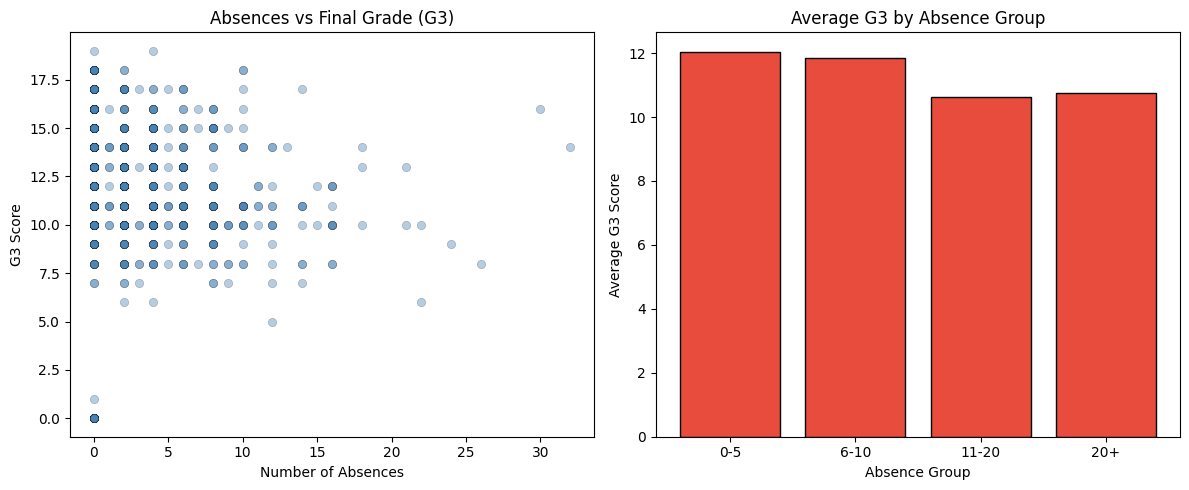

Average G3 by Absence Group:
absence_group
0-5      12.048117
6-10     11.852459
11-20    10.634146
20+      10.750000
Name: G3, dtype: float64

Correlation between absences and G3: -0.091


In [24]:
plt.figure(figsize=(12, 5))

# Plot 1 - Scatter plot: Absences vs G3
plt.subplot(1, 2, 1)
plt.scatter(df['absences'], df['G3'], alpha=0.4, color='steelblue', edgecolor='black', linewidths=0.3)
plt.title('Absences vs Final Grade (G3)')
plt.xlabel('Number of Absences')
plt.ylabel('G3 Score')

# Plot 2 - Average G3 by absence groups
plt.subplot(1, 2, 2)
bins = [0, 5, 10, 20, df['absences'].max()]
labels = ['0-5', '6-10', '11-20', '20+']
df['absence_group'] = pd.cut(df['absences'], bins=bins, labels=labels, include_lowest=True)
absence_perf = df.groupby('absence_group', observed=True)['G3'].mean()
plt.bar(absence_perf.index, absence_perf.values, color='#e74c3c', edgecolor='black')
plt.title('Average G3 by Absence Group')
plt.xlabel('Absence Group')
plt.ylabel('Average G3 Score')

plt.tight_layout()
plt.show()

print("Average G3 by Absence Group:")
print(absence_perf)
print(f"\nCorrelation between absences and G3: {df['absences'].corr(df['G3']):.3f}")

**Results:**

| Absence Group | Average G3 |
|---|---|
| 0 – 5 absences | 12.05 |
| 6 – 10 absences | 11.85 |
| 11 – 20 absences | 10.63 |
| 20+ absences | 10.75 |

**Correlation with G3: -0.091**

**Key Observations:**
- **Negative trend** — more absences generally lead to lower grades
- Students with 0-5 absences perform best with average G3 of **12.05**
- Significant drop at 11-20 absences — average falls to **10.63**, barely above pass threshold
- 20+ group slightly recovers to **10.75** — likely due to small sample size causing noise
- Correlation of **-0.091** is weak but consistent — absences alone don't determine grades but contribute as part of `risk_score`

### Does previous failure history impact on final grades?

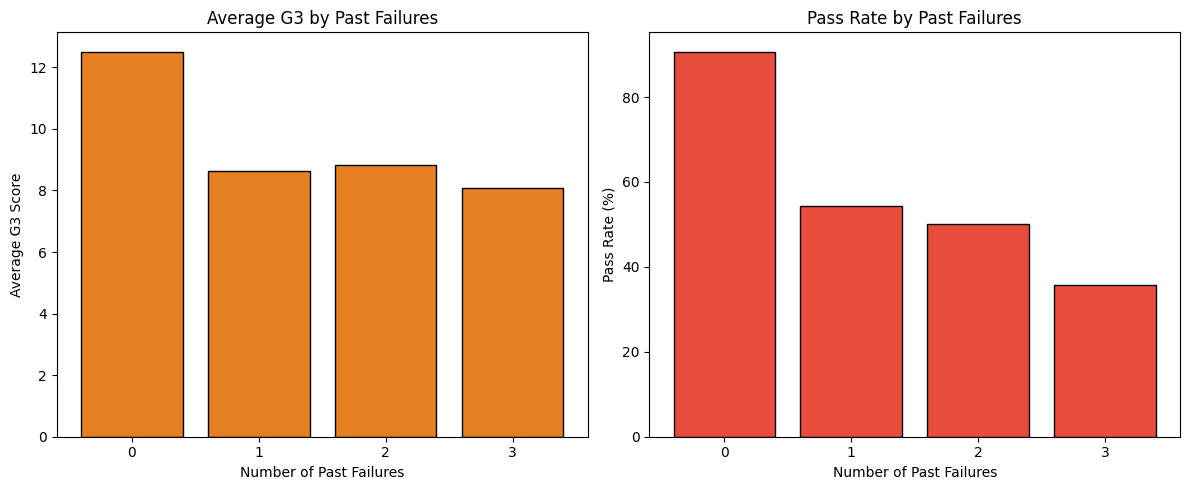

Average G3 by Past Failures:
failures
0    12.510018
1     8.642857
2     8.812500
3     8.071429
Name: G3, dtype: float64

Pass Rate by Past Failures (%):
failures
0    90.710383
1    54.285714
2    50.000000
3    35.714286
Name: pass, dtype: float64

Correlation between failures and G3: -0.393


In [25]:
plt.figure(figsize=(12, 5))

# Plot 1 - Average G3 by Failures
plt.subplot(1, 2, 1)
fail_perf = df.groupby('failures')['G3'].mean()
plt.bar(fail_perf.index, fail_perf.values, color='#e67e22', edgecolor='black')
plt.title('Average G3 by Past Failures')
plt.xlabel('Number of Past Failures')
plt.ylabel('Average G3 Score')
plt.xticks([0, 1, 2, 3])

# Plot 2 - Pass Rate by Failures
plt.subplot(1, 2, 2)
fail_pass = df.groupby('failures')['pass'].mean() * 100
plt.bar(fail_pass.index, fail_pass.values, color='#e74c3c', edgecolor='black')
plt.title('Pass Rate by Past Failures')
plt.xlabel('Number of Past Failures')
plt.ylabel('Pass Rate (%)')
plt.xticks([0, 1, 2, 3])

plt.tight_layout()
plt.show()

print("Average G3 by Past Failures:")
print(fail_perf)
print("\nPass Rate by Past Failures (%):")
print(fail_pass)
print(f"\nCorrelation between failures and G3: {df['failures'].corr(df['G3']):.3f}")

**Results:**

| Past Failures | Average G3 | Pass Rate |
|---|---|---|
| 0 failures | 12.51 | 90.7% |
| 1 failure | 8.64 | 54.3% |
| 2 failures | 8.81 | 50.0% |
| 3 failures | 8.07 | 35.7% |

**Correlation with G3: -0.393**

**Key Observations:**
- **Strongest negative predictor** in the dataset — correlation of **-0.393**
- Massive drop from 0 to 1 failure — G3 drops from **12.51 to 8.64** and pass rate crashes from **90.7% to 54.3%**
- Students with 3 past failures have only a **35.7% chance** of passing — nearly 2 in 3 will fail
- Gap between 1, 2, and 3 failures is small — suggesting that **even one failure is a major risk signal**
- This confirms why `failures` is one of the most important features in our model